# Feature Selection Analysis for IEEE-CIS Fraud Detection

This notebook performs comprehensive feature selection analysis including:
- Feature missingness analysis
- Near-constant column identification
- Numeric correlations with fraud target
- Column group summaries and visualizations

**Author:** Data Science Team  
**Date:** 2026-07-07

## 1. Setup and Installation

In [ ]:

import warnings
from pathlib import Path
from datetime import datetime

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")



Python version: 3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]
Pandas version: 3.0.3
NumPy version: 2.4.6


## 2. Mount Google Drive (for Colab)

In [ ]:
# Notebook configured for local venv execution (no Colab).
IN_COLAB = False

# Find repository root by locating data/raw (walk parents)
def find_project_root(start_path: Path = Path.cwd(), marker: str = "data/raw") -> Path:
    current = start_path.resolve()
    while True:
        if (current / marker).exists():
            return current
        if current.parent == current:
            raise FileNotFoundError(f"Could not locate {marker} under {start_path} or its parents")
        current = current.parent

# Always use local project path discovered from cwd
PROJECT_PATH = find_project_root(Path.cwd())

DATA_DIR = PROJECT_PATH / "data" / "raw"
FIGURES_DIR = PROJECT_PATH / "reports" / "figures"
SUMMARY_DIR = PROJECT_PATH / "reports" / "model_reports"

# Create directories if missing
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
SUMMARY_DIR.mkdir(parents=True, exist_ok=True)

print(f\"Project path: {PROJECT_PATH}\")
print(f\"Data directory: {DATA_DIR}\")
print(f\"Figures directory: {FIGURES_DIR}\")
print(f\"Summary directory: {SUMMARY_DIR}\")


Not running in Google Colab
Project path: C:\Users\Tinovimbanashe.Shaya\justcorp-sentinel-ai
Data directory: C:\Users\Tinovimbanashe.Shaya\justcorp-sentinel-ai\data\raw
Figures directory: C:\Users\Tinovimbanashe.Shaya\justcorp-sentinel-ai\reports\figures
Summary directory: C:\Users\Tinovimbanashe.Shaya\justcorp-sentinel-ai\reports\model_reports


## 3. Helper Functions

In [9]:
def classify_column(column_name: str) -> str:
    """
    Classify column into logical groups based on naming patterns.
    """
    if column_name == "TransactionID":
        return "identifier"
    if column_name == "isFraud":
        return "target"
    if column_name == "TransactionDT":
        return "time"
    if column_name == "TransactionAmt":
        return "amount"
    if column_name == "ProductCD":
        return "product"
    if column_name in ["DeviceType", "DeviceInfo"]:
        return "identity_device_feature"
    if column_name.startswith("card"):
        return "card_feature"
    if column_name.startswith("addr"):
        return "address_feature"
    if column_name.startswith("dist"):
        return "distance_feature"
    if column_name in ["P_emaildomain", "R_emaildomain"]:
        return "email_domain"
    if column_name.startswith("C"):
        return "count_feature"
    if column_name.startswith("D"):
        return "time_delta_feature"
    if column_name.startswith("M"):
        return "match_feature"
    if column_name.startswith("V"):
        return "anonymous_transaction_feature"
    if column_name.startswith("id_") or column_name.startswith("id-"):
        return "identity_feature"
    return "other"

def load_data() -> tuple[pd.DataFrame, pd.DataFrame]:
    """Load training data from CSV files."""
    train_transaction_file = DATA_DIR / "train_transaction.csv"
    train_identity_file = DATA_DIR / "train_identity.csv"
    
    print(f"Loading transaction data from: {train_transaction_file}")
    train_transaction = pd.read_csv(train_transaction_file)
    print(f"Transaction data shape: {train_transaction.shape}")
    
    print(f"Loading identity data from: {train_identity_file}")
    train_identity = pd.read_csv(train_identity_file)
    print(f"Identity data shape: {train_identity.shape}")
    
    return train_transaction, train_identity

## 4. Data Loading and Merging

In [10]:
# Load data
train_transaction, train_identity = load_data()

# Merge datasets
merged_df = train_transaction.merge(
    train_identity,
    on="TransactionID",
    how="left",
)

print(f"\nMerged data shape: {merged_df.shape}")
print(f"Columns count: {len(merged_df.columns)}")
print(f"\nFirst 5 rows of merged data:")
merged_df.head()

Loading transaction data from: C:\Users\Tinovimbanashe.Shaya\justcorp-sentinel-ai\data\raw\train_transaction.csv
Transaction data shape: (590540, 394)
Loading identity data from: C:\Users\Tinovimbanashe.Shaya\justcorp-sentinel-ai\data\raw\train_identity.csv
Identity data shape: (144233, 41)

Merged data shape: (590540, 434)
Columns count: 434

First 5 rows of merged data:


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


## 5. Feature Missingness Analysis

In [11]:
def calculate_feature_missingness(df: pd.DataFrame) -> pd.DataFrame:
    """Calculate missing percentage for each feature with classification."""
    records = []
    
    for column in df.columns:
        records.append({
            "column_name": column,
            "column_group": classify_column(column),
            "missing_percentage": round(df[column].isna().mean() * 100, 3),
            "unique_values": df[column].nunique(dropna=True),
            "data_type": str(df[column].dtype),
        })
    
    return pd.DataFrame(records)

missingness_df = calculate_feature_missingness(merged_df)

# Show missingness statistics
print(f"Total columns: {len(missingness_df)}")
print(f"Average missing percentage: {missingness_df['missing_percentage'].mean():.2f}%")
print(f"Median missing percentage: {missingness_df['missing_percentage'].median():.2f}%")
print(f"\nColumns with >50% missing: {len(missingness_df[missingness_df['missing_percentage'] > 50])}")
print(f"Columns with >90% missing: {len(missingness_df[missingness_df['missing_percentage'] > 90])}")

missingness_df.head(10)

Total columns: 434
Average missing percentage: 45.07%
Median missing percentage: 47.29%

Columns with >50% missing: 214
Columns with >90% missing: 12


,column_name,column_group,missing_percentage,unique_values,data_type
0,TransactionID,identifier,0.000,590540,int64
1,isFraud,target,0.000,2,int64
2,TransactionDT,time,0.000,573349,int64
3,TransactionAmt,amount,0.000,20902,float64
4,ProductCD,product,0.000,5,str
5,card1,card_feature,0.000,13553,int64
6,card2,card_feature,1.513,500,float64
7,card3,card_feature,0.265,114,float64
8,card4,card_feature,0.267,4,str
9,card5,card_feature,0.721,119,float64


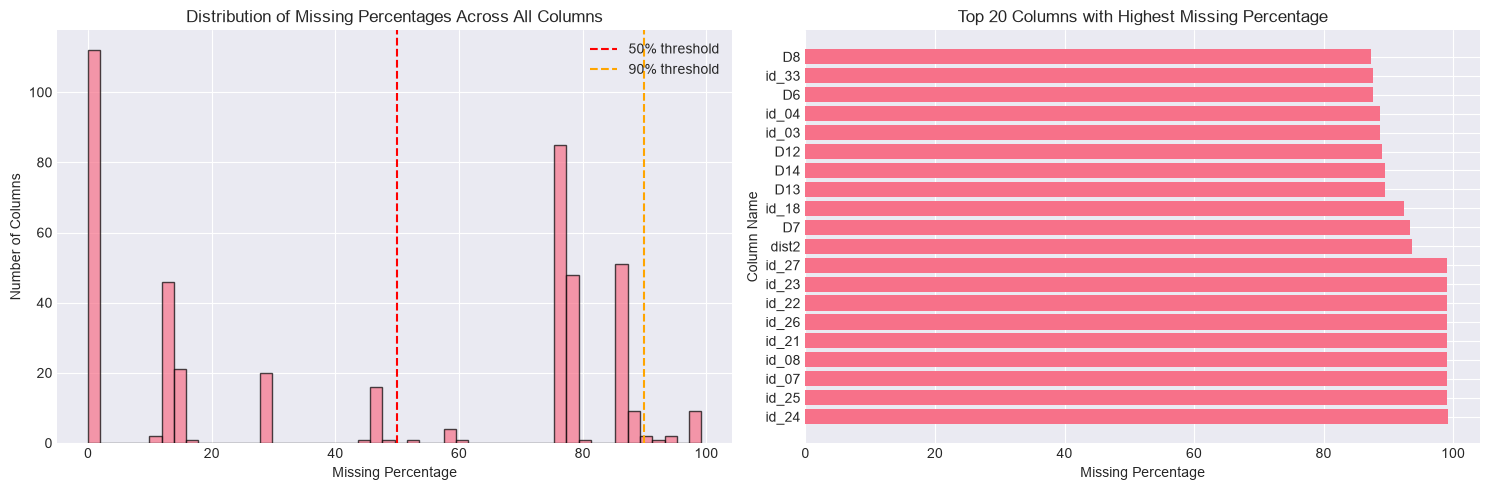

In [12]:
# Plot missingness distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribution of missing percentages
axes[0].hist(missingness_df['missing_percentage'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Missing Percentage')
axes[0].set_ylabel('Number of Columns')
axes[0].set_title('Distribution of Missing Percentages Across All Columns')
axes[0].axvline(x=50, color='red', linestyle='--', label='50% threshold')
axes[0].axvline(x=90, color='orange', linestyle='--', label='90% threshold')
axes[0].legend()

# Top 20 columns with most missing
top_missing = missingness_df.nlargest(20, 'missing_percentage')
axes[1].barh(top_missing['column_name'], top_missing['missing_percentage'])
axes[1].set_xlabel('Missing Percentage')
axes[1].set_ylabel('Column Name')
axes[1].set_title('Top 20 Columns with Highest Missing Percentage')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'missingness_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Near-Constant Column Identification

In [13]:
def identify_near_constant_columns(
    df: pd.DataFrame,
    threshold: float = 0.99,
) -> list[str]:
    """Identify columns where a single value appears more than threshold% of time."""
    near_constant_columns = []
    
    for column in df.columns:
        top_frequency = df[column].value_counts(dropna=False, normalize=True).head(1)
        
        if not top_frequency.empty and top_frequency.iloc[0] >= threshold:
            near_constant_columns.append(column)
    
    return near_constant_columns

near_constant_columns = identify_near_constant_columns(merged_df, threshold=0.99)

print(f"Near-constant columns (threshold=99%): {len(near_constant_columns)}")

# Analyze near-constant columns
if near_constant_columns:
    near_constant_df = missingness_df[missingness_df['column_name'].isin(near_constant_columns)]
    print(f"\nNear-constant columns by group:")
    print(near_constant_df['column_group'].value_counts())
    print(f"\nFirst 20 near-constant columns:")
    print(near_constant_df[['column_name', 'column_group', 'missing_percentage']].head(20))
    
    # Save list
    pd.DataFrame({'near_constant_columns': near_constant_columns}).to_csv(
        SUMMARY_DIR / 'near_constant_columns.csv', index=False
    )

Near-constant columns (threshold=99%): 24

Near-constant columns by group:
column_group
anonymous_transaction_feature    14
identity_feature                  9
count_feature                     1
Name: count, dtype: int64

First 20 near-constant columns:
    column_name                   column_group  missing_percentage
19           C3                  count_feature               0.000
161        V107  anonymous_transaction_feature               0.053
162        V108  anonymous_transaction_feature               0.053
164        V110  anonymous_transaction_feature               0.053
165        V111  anonymous_transaction_feature               0.053
166        V112  anonymous_transaction_feature               0.053
167        V113  anonymous_transaction_feature               0.053
168        V114  anonymous_transaction_feature               0.053
171        V117  anonymous_transaction_feature               0.053
172        V118  anonymous_transaction_feature               0.053
173     

## 7. Numeric Correlations with Fraud Target

In [ ]:
def calculate_numeric_correlations(df: pd.DataFrame, sample_max_rows: int = 200_000) -> pd.DataFrame:
    """Memory-safe per-column correlation with target."""
    numeric_df = df.select_dtypes(include=["number"]).copy()
    if "isFraud" not in numeric_df.columns:
        raise KeyError("isFraud column not found in numeric data")

    # Downsample rows when dataset is very large to keep memory usage bounded
    n_rows = numeric_df.shape[0]
    if n_rows > sample_max_rows:
        numeric_df = numeric_df.sample(n=sample_max_rows, random_state=42)

    target = numeric_df["isFraud"]
    correlations = []
    for col in numeric_df.columns:
        if col == "isFraud":
            continue
        try:
            corr = target.corr(numeric_df[col])
        except Exception:
            corr = float('nan')
        correlations.append((col, abs(corr) if pd.notna(corr) else float('nan'), corr))

    correlation_df = pd.DataFrame(correlations, columns=["feature_name", "absolute_correlation", "signed_correlation"])
    correlation_df = correlation_df.sort_values("absolute_correlation", ascending=False).reset_index(drop=True)
    return correlation_df

# compute correlations with a bounded sample size to avoid large mem allocations
correlation_df = calculate_numeric_correlations(merged_df, sample_max_rows=200_000)

print(f"Numeric features: {len(correlation_df)}")
print("\nTop 20 features by absolute correlation with isFraud:")
correlation_df.head(20)

Numeric features: 402

Top 20 features by absolute correlation with isFraud:


,feature_name,absolute_correlation,signed_correlation
0,V257,0.383060,0.383060
1,V246,0.366878,0.366878
2,V244,0.364129,0.364129
3,V242,0.360590,0.360590
4,V201,0.328005,0.328005
5,V200,0.318783,0.318783
6,V189,0.308219,0.308219
7,V188,0.303582,0.303582
8,V258,0.297151,0.297151
9,V45,0.281832,0.281832


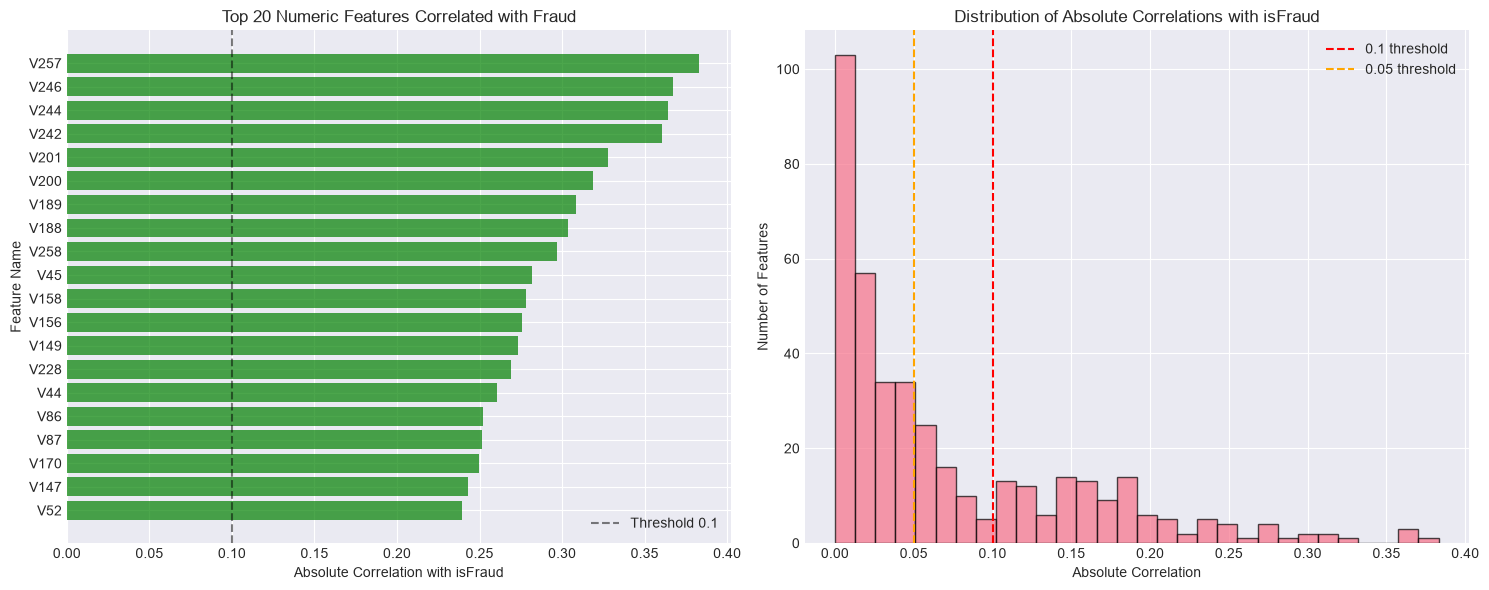


Features with absolute correlation > 0.1: 119
    feature_name  absolute_correlation  signed_correlation
0           V257              0.383060            0.383060
1           V246              0.366878            0.366878
2           V244              0.364129            0.364129
3           V242              0.360590            0.360590
4           V201              0.328005            0.328005
..           ...                   ...                 ...
114         V261              0.104785            0.104785
115          V69              0.104521           -0.104521
116         V282              0.104123            0.104123
117          V30              0.103088           -0.103088
118          V70              0.100900           -0.100900

[119 rows x 3 columns]


In [15]:
# Plot top correlations
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Top 20 absolute correlations
top_corr = correlation_df.head(20).sort_values('absolute_correlation')

colors = ['red' if x < 0 else 'green' for x in top_corr['signed_correlation']]
axes[0].barh(top_corr['feature_name'], top_corr['absolute_correlation'], color=colors, alpha=0.7)
axes[0].set_xlabel('Absolute Correlation with isFraud')
axes[0].set_ylabel('Feature Name')
axes[0].set_title('Top 20 Numeric Features Correlated with Fraud')
axes[0].axvline(x=0.1, color='black', linestyle='--', alpha=0.5, label='Threshold 0.1')
axes[0].legend()

# Distribution of correlations
axes[1].hist(correlation_df['absolute_correlation'], bins=30, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Absolute Correlation')
axes[1].set_ylabel('Number of Features')
axes[1].set_title('Distribution of Absolute Correlations with isFraud')
axes[1].axvline(x=0.1, color='red', linestyle='--', label='0.1 threshold')
axes[1].axvline(x=0.05, color='orange', linestyle='--', label='0.05 threshold')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'correlation_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Print strong correlations
strong_corr = correlation_df[correlation_df['absolute_correlation'] > 0.1]
print(f"\nFeatures with absolute correlation > 0.1: {len(strong_corr)}")
print(strong_corr) 

## 8. Feature Group Summaries

In [16]:
def create_feature_selection_summary(
    missingness_df: pd.DataFrame,
    near_constant_columns: list[str],
) -> pd.DataFrame:
    """Create summary statistics by feature group."""
    summary = (
        missingness_df.groupby("column_group")
        .agg(
            feature_count=("column_name", "count"),
            average_missing_percentage=("missing_percentage", "mean"),
            max_missing_percentage=("missing_percentage", "max"),
            average_unique_values=("unique_values", "mean"),
        )
        .reset_index()
    )
    
    summary["average_missing_percentage"] = summary["average_missing_percentage"].round(3)
    summary["max_missing_percentage"] = summary["max_missing_percentage"].round(3)
    summary["average_unique_values"] = summary["average_unique_values"].round(3)
    
    summary["near_constant_columns_in_group"] = summary["column_group"].apply(
        lambda group: sum(
            missingness_df[
                (missingness_df["column_group"] == group)
                & (missingness_df["column_name"].isin(near_constant_columns))
            ].shape
        )
    )
    
    return summary.sort_values("feature_count", ascending=False)

summary_df = create_feature_selection_summary(
    missingness_df,
    near_constant_columns,
)

summary_df

,column_group,feature_count,average_missing_percentage,max_missing_percentage,average_unique_values,near_constant_columns_in_group
2,anonymous_transaction_feature,339,43.038,86.124,1550.631,19
9,identity_feature,38,84.823,99.196,3136.658,14
14,time_delta_feature,15,58.151,93.410,1439.800,5
4,count_feature,14,0.000,0.000,1069.929,6
10,match_feature,9,49.923,59.349,2.111,5
3,card_feature,6,0.505,1.513,2382.333,5
5,distance_feature,2,76.640,93.628,2201.000,5
0,address_feature,2,11.126,11.126,203.000,5
6,email_domain,2,46.374,76.752,59.500,5
8,identity_device_feature,2,78.031,79.906,894.000,5


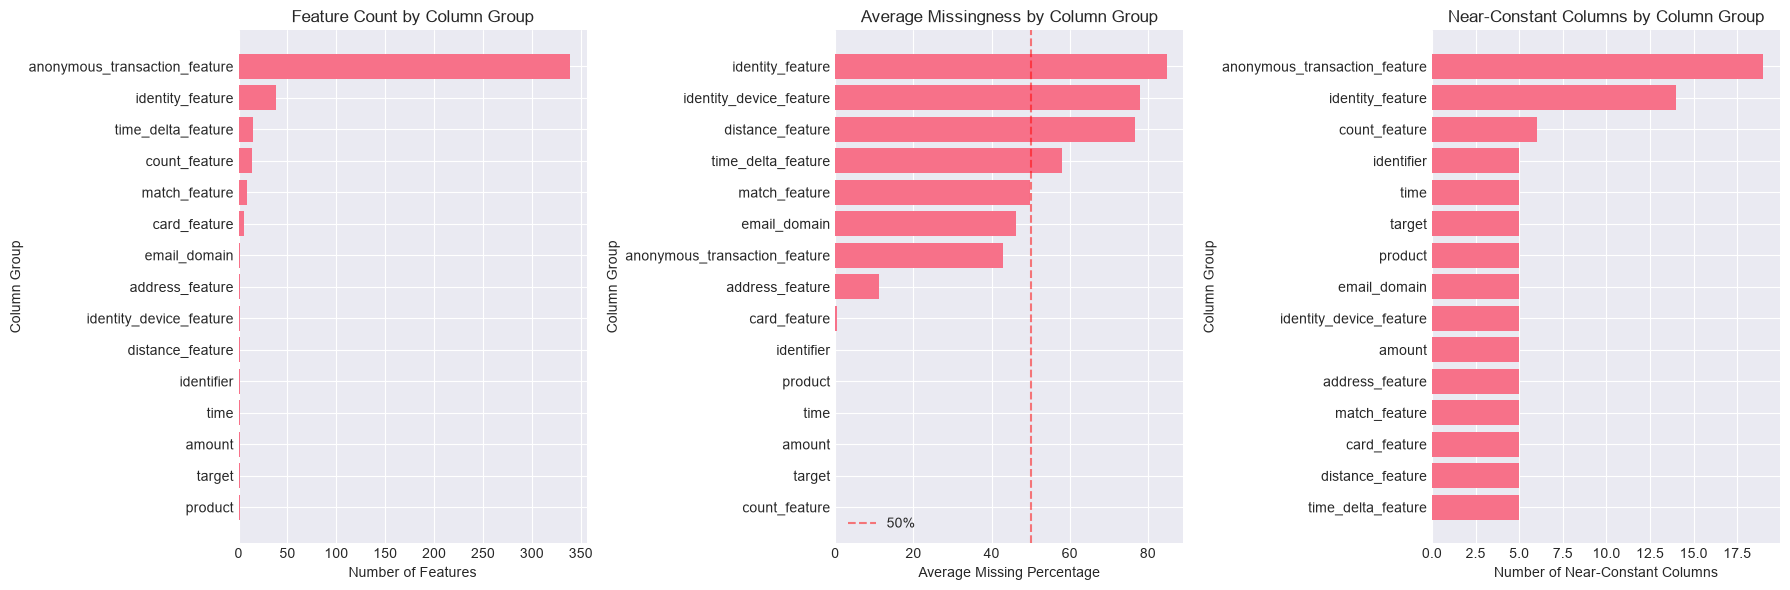

In [17]:
# Visualize feature group summaries
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Feature count by group
plot_df1 = summary_df.sort_values('feature_count')
axes[0].barh(plot_df1['column_group'], plot_df1['feature_count'])
axes[0].set_xlabel('Number of Features')
axes[0].set_ylabel('Column Group')
axes[0].set_title('Feature Count by Column Group')

# 2. Average missingness by group
plot_df2 = summary_df.sort_values('average_missing_percentage')
axes[1].barh(plot_df2['column_group'], plot_df2['average_missing_percentage'])
axes[1].set_xlabel('Average Missing Percentage')
axes[1].set_ylabel('Column Group')
axes[1].set_title('Average Missingness by Column Group')
axes[1].axvline(x=50, color='red', linestyle='--', alpha=0.5, label='50%')
axes[1].legend()

# 3. Near-constant columns by group
plot_df3 = summary_df.sort_values('near_constant_columns_in_group')
axes[2].barh(plot_df3['column_group'], plot_df3['near_constant_columns_in_group'])
axes[2].set_xlabel('Number of Near-Constant Columns')
axes[2].set_ylabel('Column Group')
axes[2].set_title('Near-Constant Columns by Column Group')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'feature_group_summary.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Complete Feature Selection Report

In [18]:
def print_feature_selection_report(
    missingness_df: pd.DataFrame,
    correlation_df: pd.DataFrame,
    near_constant_columns: list[str],
    summary_df: pd.DataFrame,
) -> None:
    """Print comprehensive feature selection report."""
    print("\n" + "="*80)
    print("FEATURE SELECTION ANALYSIS REPORT")
    print("="*80)
    print(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print("="*80)
    
    print("\n1. COLUMN GROUP SUMMARY")
    print("-" * 80)
    print(summary_df.to_string(index=False))
    
    print("\n\n2. TOP CORRELATIONS WITH FRAUD TARGET")
    print("-" * 80)
    print(correlation_df.head(20).to_string(index=False))
    
    print("\n\n3. NEAR-CONSTANT COLUMNS")
    print("-" * 80)
    print(f"Total near-constant columns: {len(near_constant_columns)}")
    if near_constant_columns:
        print("\nFirst 20 near-constant columns:")
        print(near_constant_columns[:20])
    
    print("\n\n4. HIGH MISSINGNESS COLUMNS (>90%)")
    print("-" * 80)
    high_missing = missingness_df[missingness_df["missing_percentage"] >= 90]
    if not high_missing.empty:
        print(high_missing[["column_name", "column_group", "missing_percentage"]].to_string(index=False))
    else:
        print("No columns with >90% missing values")
    
    print("\n\n5. RECOMMENDATIONS")
    print("-" * 80)
    
    # Recommendations based on analysis
    high_missing_count = len(missingness_df[missingness_df['missing_percentage'] > 50])
    if high_missing_count > 10:
        print(f"- Consider dropping or imputing {high_missing_count} columns with >50% missing values")
    
    if len(correlation_df[correlation_df['absolute_correlation'] > 0.1]) > 5:
        print("- Strong correlations detected (>0.1): Consider these for feature selection")
    
    if len(near_constant_columns) > 10:
        print(f"- {len(near_constant_columns)} near-constant columns: Consider dropping them")
    
    if summary_df['feature_count'].sum() > 100:
        print("- Large feature set: Consider dimensionality reduction techniques")
    
    print("\n" + "="*80)

print_feature_selection_report(
    missingness_df,
    correlation_df,
    near_constant_columns,
    summary_df,
)


FEATURE SELECTION ANALYSIS REPORT
Generated: 2026-07-07 13:30:53

1. COLUMN GROUP SUMMARY
--------------------------------------------------------------------------------
                 column_group  feature_count  average_missing_percentage  max_missing_percentage  average_unique_values  near_constant_columns_in_group
anonymous_transaction_feature            339                      43.038                  86.124               1550.631                              19
             identity_feature             38                      84.823                  99.196               3136.658                              14
           time_delta_feature             15                      58.151                  93.410               1439.800                               5
                count_feature             14                       0.000                   0.000               1069.929                               6
                match_feature              9                      49

## 10. Save Results

In [20]:
# Save all results
missingness_df.to_csv(SUMMARY_DIR / "feature_missingness_summary.csv", index=False)
correlation_df.to_csv(SUMMARY_DIR / "numeric_correlations_with_fraud.csv", index=False)
summary_df.to_csv(SUMMARY_DIR / "feature_selection_summary.csv", index=False)

print(f"✅ Feature missingness saved to: {SUMMARY_DIR / 'feature_missingness_summary.csv'}")
print(f"✅ Numeric correlations saved to: {SUMMARY_DIR / 'numeric_correlations_with_fraud.csv'}")
print(f"✅ Feature selection summary saved to: {SUMMARY_DIR / 'feature_selection_summary.csv'}")
print(f"✅ Figures saved to: {FIGURES_DIR}")
print(f"✅ Near-constant columns list saved to: {SUMMARY_DIR / 'near_constant_columns.csv'}")

# Create a comprehensive markdown report
def safe_to_markdown(df: pd.DataFrame) -> str:
    try:
        return df.to_markdown(index=False)
    except Exception:
        return df.to_string(index=False)

summary_md = safe_to_markdown(summary_df)
top_corr_md = safe_to_markdown(correlation_df.head(10))

report_content = f"""# Feature Selection Analysis Report

**Generated:** {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

## Overview
- **Total features:** {len(missingness_df)}
- **Target variable:** isFraud (Fraudulent transactions)
- **Data shape:** {merged_df.shape}

## Feature Missingness Summary
- Average missing percentage: {missingness_df['missing_percentage'].mean():.2f}%
- Median missing percentage: {missingness_df['missing_percentage'].median():.2f}%
- Columns with >50% missing: {len(missingness_df[missingness_df['missing_percentage'] > 50])}
- Columns with >90% missing: {len(missingness_df[missingness_df['missing_percentage'] > 90])}

## Near-Constant Features
- Threshold: 99%
- Count: {len(near_constant_columns)}

## Feature Group Summary
{summary_md}

## Top Correlations with Fraud
Top 10 features with highest absolute correlation with isFraud:
{top_corr_md}

## Recommendations
- Consider dropping or imputing columns with high missingness
- Use correlation analysis for feature selection
- Consider PCA or other dimensionality reduction techniques for large feature sets
"""

with open(SUMMARY_DIR / "feature_selection_report.md", "w") as f:
    f.write(report_content)

print(f"✅ Markdown report saved to: {SUMMARY_DIR / 'feature_selection_report.md'}")

✅ Feature missingness saved to: C:\Users\Tinovimbanashe.Shaya\justcorp-sentinel-ai\reports\model_reports\feature_missingness_summary.csv
✅ Numeric correlations saved to: C:\Users\Tinovimbanashe.Shaya\justcorp-sentinel-ai\reports\model_reports\numeric_correlations_with_fraud.csv
✅ Feature selection summary saved to: C:\Users\Tinovimbanashe.Shaya\justcorp-sentinel-ai\reports\model_reports\feature_selection_summary.csv
✅ Figures saved to: C:\Users\Tinovimbanashe.Shaya\justcorp-sentinel-ai\reports\figures
✅ Near-constant columns list saved to: C:\Users\Tinovimbanashe.Shaya\justcorp-sentinel-ai\reports\model_reports\near_constant_columns.csv
✅ Markdown report saved to: C:\Users\Tinovimbanashe.Shaya\justcorp-sentinel-ai\reports\model_reports\feature_selection_report.md


## 11. Summary and Next Steps

In [ ]:
print("="*80)
print("FEATURE SELECTION ANALYSIS COMPLETE")
print("="*80)
print("\n✅ Analysis completed successfully!")
print(f"\n📊 Feature groups analyzed: {len(summary_df)}")
print(f"📈 Numeric features correlated: {len(correlation_df)}")
print(f"🗑️ Near-constant columns: {len(near_constant_columns)}")
print(f"📉 Missingness analyzed for all features")
print(f"\n📁 All results saved to: {SUMMARY_DIR}")
print(f"📊 Visualizations saved to: {FIGURES_DIR}")
print("\n" + "="*80)